# CNN Training

Trains a sketch denoising CNN (`SketchDenoiser`) on synthetic SVG images.

SVGs are sampled from `data/svg_dataset.csv`, converted to stroke-only images,
and augmented with Perlin noise to simulate hand-drawn input.

Set `USE_RAY = True` to offload generation + training to a remote Ray cluster.

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt

In [ ]:
from meta import ROOT_DIR

## Configuration

In [ ]:
USE_RAY = True

N_IMAGES = 3000
D_IMAGE = 256
N_EPOCH = 30
BATCH_SIZE = 50
LR = 0.005
D_MODEL = 32
STD_NOISE = 0.05

## Dataset CSV

Downloaded automatically from HuggingFace if not already present.
Requires `HF_TOKEN` in `.env`.

In [ ]:
import dotenv
import os

dotenv.load_dotenv(ROOT_DIR / ".env")
hf_token = os.environ.get("HF_TOKEN", "")

In [ ]:
from sketchy_cnn.dataset import ensure_hf_dataset

csv_path = ROOT_DIR / "data" / "svg_dataset.csv"
ensure_hf_dataset(csv_path, hf_token)
csv_bytes = csv_path.read_bytes()

## Dataset images

In [ ]:
from sketchy_cnn.dataset import SVGDataset

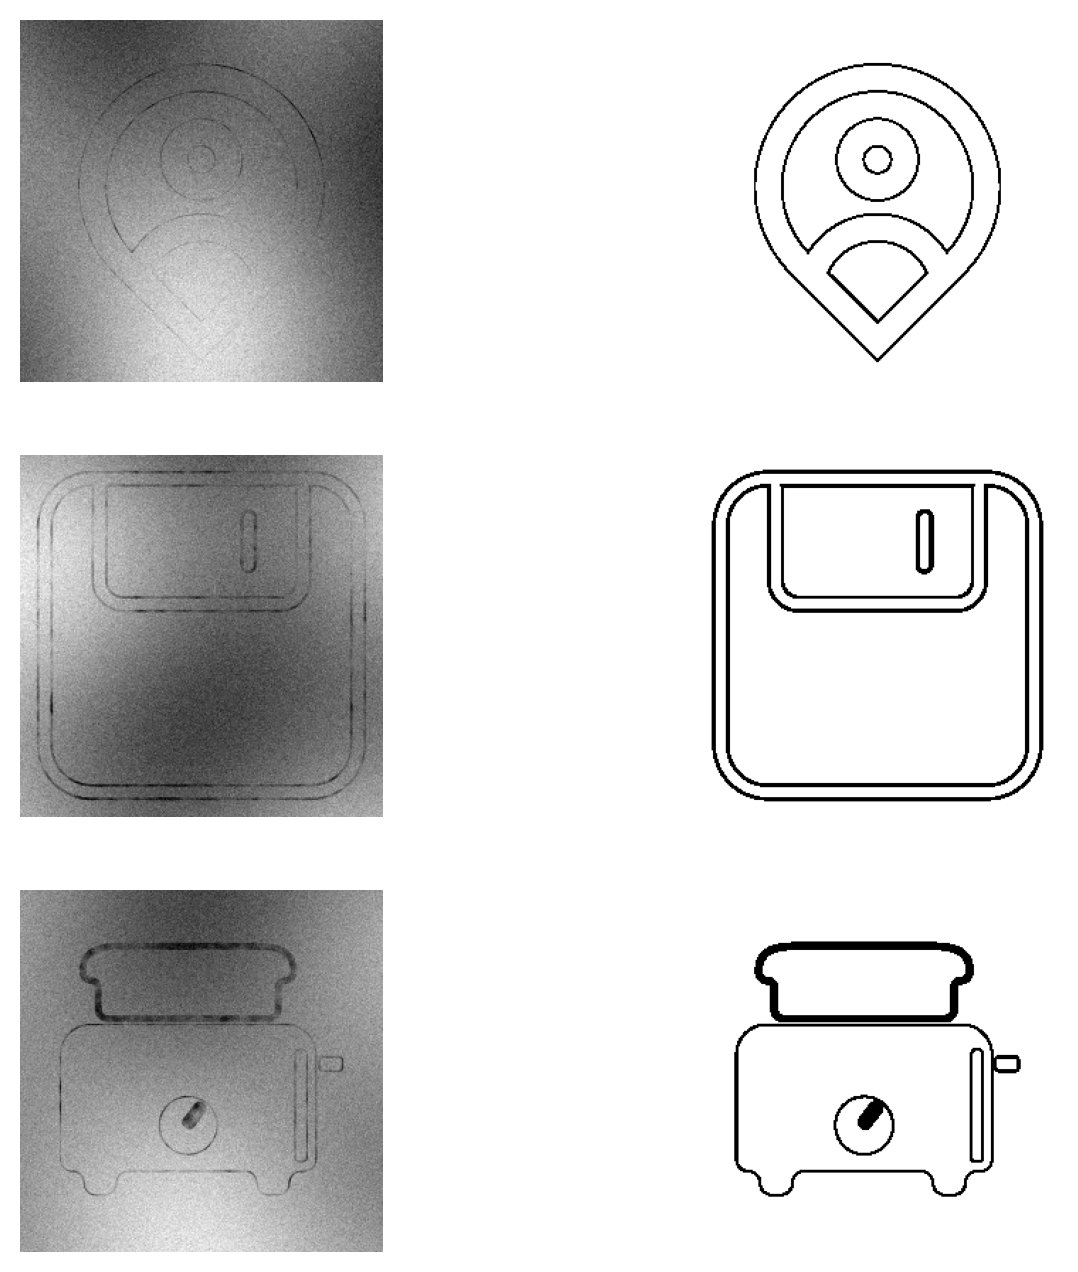

In [ ]:
demo_dataset = SVGDataset.from_csv(
    csv_bytes, n=3, d=D_IMAGE, std_noise=STD_NOISE
)
_fig, axes = plt.subplots(3, 2, figsize=(8, 8))
for i in range(3):
    for j in range(2):
        axes[i, j].imshow(demo_dataset[i][j][0], cmap="binary")
        axes[i, j].axis(False)
_fig

## Training function

In [ ]:
import torch
from sketchy_cnn import SketchDenoiser

In [ ]:
def train_fn(
    csv_bytes, n_images, d_image, d_model, n_epoch, batch_size, lr, std_noise
):
    dataset = SVGDataset.from_csv(
        csv_bytes, n=n_images, d=d_image, std_noise=std_noise
    )
    dataloader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SketchDenoiser(d_model).to(device)
    criterion = torch.nn.BCELoss()
    opti = torch.optim.AdamW(model.parameters(), lr=lr)

    losses = []
    for epoch in range(n_epoch):
        epoch_loss = 0.0
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            opti.zero_grad()
            y_pred = model(batch_x)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            opti.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{n_epoch}, Loss: {avg_loss:.4f}")

    return model.cpu().state_dict(), losses

## Run training

In [ ]:
_widget = None
if USE_RAY:
    from rayrun import RayRun
    _widget = RayRun()
_widget

ModuleNotFoundError: No module named 'rayrun'

In [ ]:
kwargs = dict(
    csv_bytes=csv_bytes,
    n_images=N_IMAGES,
    d_image=D_IMAGE,
    d_model=D_MODEL,
    n_epoch=N_EPOCH,
    batch_size=BATCH_SIZE,
    lr=LR,
    std_noise=STD_NOISE,
)

    import ray


    ray.init(RAY_ADDRESS)
    state_dict, losses = ray.get(ray.remote(num_gpus=1)(train_fn).remote(**kwargs))
else:
    state_dict, losses = train_fn(**kwargs)

[E 260224 08:43:34 cell_runner:582] Unexpected error type: 


exception: UnknownError(msg='', error_type=None)

## Loss curve

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(losses)), losses, label="reconstruction loss")
plt.title("Reconstruction loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.gca()

ancestor-stopped: This cell wasn't run because an ancestor was stopped with `mo.stop`

## Visualisation

In [ ]:
from io import BytesIO
import base64

def figure(data, w=D_IMAGE, h=D_IMAGE, cmap="binary"):
    import matplotlib.pyplot as _plt

    fig = _plt.figure()
    ax = fig.gca()
    ax.imshow(data.reshape(h, w), cmap=cmap)
    ax.axis(False)
    buf = BytesIO()
    fig.savefig(buf, format="png")
    buf.seek(0)
    img_b64 = base64.b64encode(buf.getvalue()).decode()
    _plt.close(fig)
    return mo.Html(f'<img src="data:image/png;base64,{img_b64}" />')

def table(data):
    import polars as pl

    df = pl.DataFrame(data)
    parts = ["<table><thead><tr>"]
    for col in df.columns:
        parts.append(f'<th style="text-align:center">{col}</th>')
    parts.append("</tr></thead><tbody>")
    for row in df.iter_rows(named=False):
        parts.append("<tr>")
        for cell in row:
            parts.append(f"<td>{cell}</td>")
        parts.append("</tr>")
    parts.append("</tbody></table>")
    return mo.Html("".join(parts))

In [ ]:
_model_viz = SketchDenoiser(32)
_model_viz.load_state_dict({k: v.cpu() for k, v in state_dict.items()})
_model_viz.eval()

_dataset_viz = SVGDataset.from_csv(csv_bytes, n=10, d=D_IMAGE)
_samples = [_dataset_viz[i] for i in range(6)]
_xs = torch.stack([s[0] for s in _samples])
_ys = torch.stack([s[1] for s in _samples])

with torch.no_grad():
    _preds = _model_viz(_xs)

table(
    {
        "Input": [figure(x).text for x in _xs],
        "Predicted": [figure(p).text for p in _preds],
        "Ground truth": [figure(y).text for y in _ys],
    }
)

## ONNX export

In [ ]:
_model_export = SketchDenoiser(32)
_model_export.load_state_dict({k: v.cpu() for k, v in state_dict.items()})
_model_export.eval()

_dummy = torch.rand((1, 1, 256, 256), dtype=torch.float32)
_out_path = ROOT_DIR / "src" / "sketchy_cnn" / "model.onnx"

torch.onnx.export(
    _model_export,
    (_dummy,),
    _out_path,
    input_names=["input"],
    output_names=["output"],
    export_params=True,
    dynamic_axes={
        "input": {2: "height", 3: "width"},
        "output": {2: "height", 3: "width"},
    },
    dynamo=True,
)
print(f"Model exported to {_out_path}")